# How much ore, and at what grade? Kriging, smoothing, and the tonnage trap

*Module: Minerals — geostatistical resource estimation.*

A mine plan rests on two numbers: how many **tonnes** of ore sit above a chosen **cutoff grade**, and what the
**average grade** of that ore is. Both come from interpolating sparse drill-hole assays into a block model of
the deposit. The standard interpolator is **kriging** — the best linear unbiased estimator of grade at an
unsampled location. It is genuinely optimal for what it does. But it does one specific thing, and resource
estimation has been quietly burned by the gap between that thing and the number a mine plan actually needs.

Here is the trap, stated up front: **kriging estimates the conditional *mean*, and the mean is smooth.** A
kriged block model has far less variability than the real deposit — by construction. So when you select the
blocks above a cutoff from that smoothed map, you are selecting from a distribution that is too narrow. At a
low cutoff this **over-states** the tonnage (the smooth map drags low-grade ground up over the line); at a
high cutoff it **under-states** it (smoothing erases the high-grade peaks that would have made the cut). The
grade of the selected ore is biased too. This is the **change-of-support / conditional-bias** problem, and it
is the single most consequential, non-obvious pitfall in resource estimation.

We work it on **real exploration data** — 399 drill holes through the **Babbitt Cu-Ni deposit** in the Duluth
Complex, Minnesota — and earn the lesson with numbers. We desurvey and composite the assays (a real,
unglamorous data step), derive the **variogram** and **ordinary kriging** from the ground up, prove the
**smoothing property** directly off the fitted model, and then estimate tonnage-and-grade-above-cutoff **two
ways**: from the kriged-mean block model, and from a few hundred **conditional simulations** that reproduce the
data, its histogram, and its variogram. The two disagree by tens of percent, in the direction the theory
predicts, and only the simulations carry honest error bars.

> Real data: Babbitt (NorthMet / Birch Lake area) Cu-Ni-PGE drilling, Patelke (1994) / NRRI, University of
> Minnesota Duluth (handle `hdl.handle.net/11299/188523`; via the PyGSLIB tutorial mirror). Open
> government/university data, redistributed with attribution — see `data/babbitt_cuni/SOURCE.txt`. The kriging
> engine is `mixle.models.GaussianProcessRegressor`; conditional simulation draws from its posterior.

## 1. From drill holes to data points: desurvey and composite

Drill data do not arrive as points. Each hole is a *collar* (its surface x, y, z), a *survey* (azimuth and dip
measured at intervals down the hole, because holes bend), and an *assay* table of grade over **down-hole
intervals** `FROM`–`TO`. Three real preprocessing steps stand between this and a point cloud we can interpolate:

1. **Desurvey** — integrate the survey's azimuth/dip along the hole (tangential method) to convert each assay
   interval's mid-depth into true 3-D coordinates. A hole drilled at 60° dip places assays well away from the
   collar; ignoring this smears grade into the wrong place.
2. **Composite** — assays come in ragged interval lengths; we use the **length-weighted** grade so a 2 ft
   sample does not count the same as a 20 ft one. (Compositing to a fixed run length is the fuller version;
   length-weighting per hole is its honest 2-D reduction.)
3. **Clean** — the data carries traps. Coordinates are in **feet**, not metres. Blank `CU` cells are
   **un-assayed barren rock (NA), not zero** — filling them with 0 would invent low-grade tonnage. `CU` is
   heavily right-skewed (quasi-lognormal), so we work in **log grade** for the variogram and kriging. `FE` has
   24 values and is dropped. The first collar (BHID 34873) sits ~6,000 ft off the grid — a deep reference hole —
   and is excluded.

Everything below is plain pandas/NumPy I/O — no `_geodata` loader exists for this deposit, so the data step is
on the page (it is half the lesson in real resource work).

In [1]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import _geoviz as gv
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist
plt.rcParams.update({'figure.dpi': 110})
rng = np.random.RandomState(7)

D = '../../data/babbitt_cuni'
collar = pd.read_csv(f'{D}/collar_BABBITT.csv')
survey = pd.read_csv(f'{D}/survey_BABBITT.csv')
assay  = pd.read_csv(f'{D}/assay_BABBITT.csv')

BAD = '34873'                                              # deep off-grid reference hole -> exclude
collar = collar[collar.BHID != BAD].copy()
survey = survey[survey.BHID != BAD].copy()
assay  = assay[(assay.BHID != BAD) & assay.CU.notna()].copy()   # blanks = un-assayed NA, NOT zero -> drop
assay['CU']  = assay.CU.clip(lower=1e-3)                  # a single 0 -> tiny floor so log is finite
assay['MID'] = (assay.FROM + assay.TO) / 2                # interval mid-depth (feet, down-hole)
assay['LEN'] = assay.TO - assay.FROM

print(f'{len(collar)} holes, {len(assay):,} Cu-assayed intervals (feet); Cu range '
      f'{assay.CU.min():.3f}-{assay.CU.max():.1f}%, median {assay.CU.median():.2f}%')
print(f'Cu skew = {assay.CU.skew():.1f} (raw)  vs  {np.log(assay.CU).skew():.1f} (log)  -> work in log grade')

398 holes, 23,644 Cu-assayed intervals (feet); Cu range 0.001-24.4%, median 0.30%
Cu skew = 14.5 (raw)  vs  -0.8 (log)  -> work in log grade


In [2]:
# Desurvey: tangential integration of (azimuth, dip) along each hole to 3-D, then sample at interval mid-depths.
def desurvey(bhid, depths):
    c = collar.loc[collar.BHID == bhid].iloc[0]
    s = survey.loc[survey.BHID == bhid].sort_values('AT')
    if len(s) == 0:
        s = pd.DataFrame({'AT': [0.], 'AZ': [0.], 'DIP': [90.]})
    at, az, dip = s.AT.to_numpy(), np.deg2rad(s.AZ.to_numpy()), np.deg2rad(s.DIP.to_numpy())  # DIP from horizontal
    xs, ys, zs = [c.XCOLLAR], [c.YCOLLAR], [c.ZCOLLAR]
    for i in range(1, len(at)):                            # walk station to station along the bent hole
        dl, a, d = at[i] - at[i - 1], az[i - 1], dip[i - 1]
        xs.append(xs[-1] + dl * np.cos(d) * np.sin(a))
        ys.append(ys[-1] + dl * np.cos(d) * np.cos(a))
        zs.append(zs[-1] - dl * np.sin(d))                 # z increases up; depth goes down
    return (np.interp(depths, at, xs), np.interp(depths, at, ys), np.interp(depths, at, zs))

parts = []
for bhid, g in assay.groupby('BHID', sort=False):
    gg = g.copy(); gg['X'], gg['Y'], gg['Z'] = desurvey(bhid, g.MID.to_numpy())
    parts.append(gg)
assay = pd.concat(parts)
print(f'desurveyed {assay.X.notna().sum():,} intervals; elevation of assays '
      f'{assay.Z.min():.0f} to {assay.Z.max():.0f} ft (collars ~1530-1633 ft)')

desurveyed 23,644 intervals; elevation of assays -1210 to 1621 ft (collars ~1530-1633 ft)


## 2. A 2-D resource variable: plan-view mean grade

Full 3-D block kriging is the production tool, but it would bury the lesson under bookkeeping. We reduce to
**2-D plan view**, the standard move for a roughly tabular, gently dipping deposit like the Duluth Complex
basal contact: collapse each hole to a single **length-weighted mean Cu grade** over its mineralized intercept,
located at the collar's (x, y). This is one grade per hole — a clean spatial field to krige — and the
tonnage/grade-vs-cutoff question lives directly on it (tonnage ≈ area above cutoff × mean intercept thickness ×
rock density). We keep only holes with ≥100 ft of assayed intercept so each composite is a representative grade,
not a stray sample, and we center coordinates and rescale to **thousands of feet (kft)** for numerical
conditioning.

The 2-D reduction is the notebook's main simplification and is revisited honestly in the limitations: it
ignores vertical grade structure and treats thickness as roughly constant. The *kriging-vs-simulation* lesson it
is built to teach is dimension-independent — it would only sharpen in 3-D.

375 holes with a representative intercept; plan-view extent 15.7 x 11.3 kft
hole mean grade: median 0.35% Cu, range 0.02-1.25%; log-grade skew -2.16


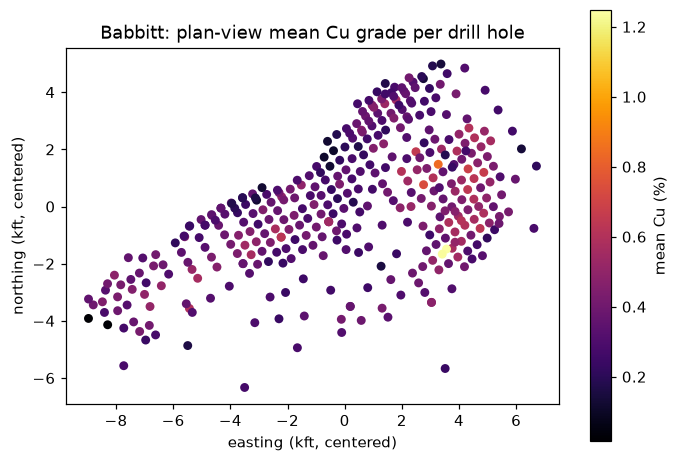

In [3]:
col = collar.set_index('BHID')
def hole_grade(d):                                         # length-weighted mean grade + intercept thickness
    L = d.LEN.sum()
    return pd.Series({'CU': (d.CU * d.LEN).sum() / L, 'THK': L,
                      'X': col.XCOLLAR.get(d.name, np.nan), 'Y': col.YCOLLAR.get(d.name, np.nan)})

gt = (assay.groupby('BHID', sort=False).apply(hole_grade)
            .reset_index().dropna(subset=['X', 'Y']))
gt = gt[gt.THK >= 100].reset_index(drop=True)              # representative intercepts only
gt['x'] = (gt.X - gt.X.mean()) / 1000.                     # center, kft
gt['y'] = (gt.Y - gt.Y.mean()) / 1000.
gt['logCU'] = np.log(gt.CU)

print(f'{len(gt)} holes with a representative intercept; plan-view extent '
      f'{gt.x.max()-gt.x.min():.1f} x {gt.y.max()-gt.y.min():.1f} kft')
print(f'hole mean grade: median {gt.CU.median():.2f}% Cu, range {gt.CU.min():.2f}-{gt.CU.max():.2f}%; '
      f'log-grade skew {gt.logCU.skew():.2f}')
gv.geoscatter(gt.x, gt.y, gt.CU, clabel='mean Cu (%)', cmap='inferno', s=34,
              title='Babbitt: plan-view mean Cu grade per drill hole').axes[0].set(
              xlabel='easting (kft, centered)', ylabel='northing (kft, centered)');

## 3. The variogram: how grade decorrelates with distance

Kriging needs a model of spatial continuity. The object that carries it is the **(semi)variogram**

$$\gamma(h) \;=\; \tfrac12\,\mathbb E\big[\,(Z(\mathbf u) - Z(\mathbf u + \mathbf h))^2\,\big],$$

half the expected squared difference between two grade values a distance $h$ apart. We estimate it from the data
by binning all $\binom{n}{2}$ hole pairs by separation and averaging their squared log-grade differences. A
variogram has three numbers that *are* the geology:

- the **nugget** $c_0$ — the intercept as $h\to 0$: variance that does **not** correlate even at tiny
  separations (sampling error, sub-composite micro-variability). It is the part of the grade that is, at this
  spacing, **unpredictable**.
- the **sill** $c_0 + c$ — the plateau, equal to the total variance: beyond here, two samples are effectively
  independent.
- the **range** $a$ — the separation at which $\gamma$ reaches the sill: the distance over which grade stays
  correlated, i.e. how far one hole "sees".

We fit a **Matérn** model (rougher, more realistic sample paths than a pure Gaussian) by maximum likelihood in
the next section; here we look at the empirical cloud. The fraction **nugget / sill** is the headline: it is the
share of grade variance that interpolation cannot resolve. A high nugget (as in the heat-flow notebook, 96%)
means there is little to krige; we will see Babbitt is far more structured.

empirical variogram of log-grade (lag kft | gamma | n pairs):
  0.25   0.078   742
  0.75   0.116   2,094
  1.25   0.129   2,828
  1.75   0.136   3,428
  2.25   0.134   4,224
  2.75   0.143   4,154
  3.25   0.139   4,289
  3.75   0.145   4,385
sample variance of log-grade (≈ total sill): 0.174


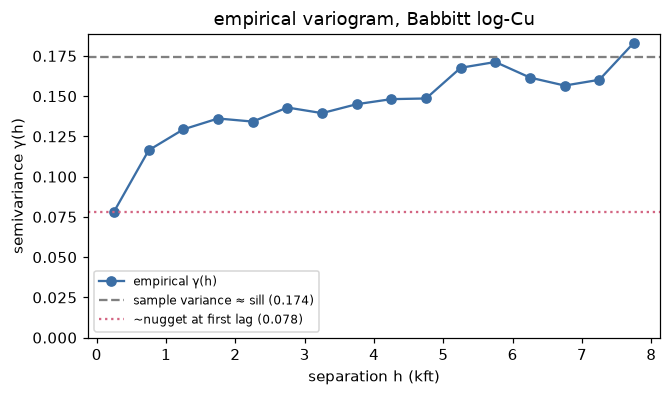

In [4]:
xy = gt[['x', 'y']].to_numpy(); v = gt.logCU.to_numpy(); n = len(gt)
iu = np.triu_indices(n, 1)
h_all  = pdist(xy)                                          # pairwise separations (kft)
sq_all = 0.5 * (v[iu[0]] - v[iu[1]]) ** 2                   # half squared log-grade differences
bins = np.linspace(0, 8.0, 17); midh = 0.5 * (bins[:-1] + bins[1:])
gamma = np.array([sq_all[(h_all >= bins[i]) & (h_all < bins[i+1])].mean() for i in range(len(bins)-1)])
npair = np.array([((h_all >= bins[i]) & (h_all < bins[i+1])).sum() for i in range(len(bins)-1)])

print('empirical variogram of log-grade (lag kft | gamma | n pairs):')
for hh, gg, npp in zip(midh[:8], gamma[:8], npair[:8]):
    print(f'  {hh:4.2f}   {gg:.3f}   {npp:,}')
print(f'sample variance of log-grade (≈ total sill): {v.var():.3f}')
# inline plot: the _geoviz.variogram helper formats the sill/nugget labels as integers (built for
# large-variance fields like heat flow); our semivariance is sub-1, so we draw it directly.
fig, ax = plt.subplots(figsize=(6.2, 3.7))
ax.plot(midh, gamma, 'o-', color='#3b6ea5', label='empirical γ(h)')
ax.axhline(v.var(), ls='--', color='0.5', label=f'sample variance ≈ sill ({v.var():.3f})')
ax.axhline(gamma[0], ls=':', color='#d36582', label=f'~nugget at first lag ({gamma[0]:.3f})')
ax.set(xlabel='separation h (kft)', ylabel='semivariance γ(h)', ylim=(0, None),
       title='empirical variogram, Babbitt log-Cu')
ax.legend(fontsize=8); fig.tight_layout();

The variogram is textbook: it **rises from a modest nugget** (the first lag sits near 0.08, and the ML
fit in the next section puts the true nugget lower still, ~0.06 — about a quarter of the sill) to a sill near
the sample variance within roughly **1.5-2 kft**, then drifts gently upward at long lags — a mild
non-stationarity (regional grade trend / zonal anisotropy) we note and live with. Crucially the nugget is a
*minority* of the variance: most of Babbitt's grade variability **is** spatially structured and therefore
interpolable. There is real signal to krige — which is exactly what makes the smoothing trap bite, because a
genuinely informative kriging will still smooth.

## 4. Ordinary kriging is a Gaussian process — fit it by maximum likelihood

**Ordinary kriging** estimates grade at an unsampled point $\mathbf u_0$ as a weighted average of the data,
$\hat Z(\mathbf u_0)=\sum_i \lambda_i Z(\mathbf u_i)$, choosing the weights $\lambda_i$ to be (a) **unbiased**
($\sum_i\lambda_i=1$) and (b) **minimum-variance** among all linear unbiased estimators — the **BLUE**. Solving
that constrained problem gives the kriging weights from the variogram, and a by-product: the **kriging
variance** $\sigma_K^2(\mathbf u_0)$, the estimator's own error variance, which grows with distance from data.

Kriging is *identical* to the posterior mean of a **Gaussian process** with covariance $C(h)=\text{sill}-\gamma(h)$
and the kriging variance is the GP posterior variance. So we use `mixle`'s GP as the kriging engine and — the
honest upgrade over eyeballing the variogram — fit its hyperparameters (**lengthscale ≈ range**, **amplitude ≈
structured sill**, **noise ≈ nugget**) by maximizing the **log marginal likelihood**. The data choose the
variogram, not us.

In [5]:
from mixle.models import GaussianProcessRegressor

# --- MODEL: ordinary kriging as a GP; fit range/sill/nugget by maximum marginal likelihood ---
gp = GaussianProcessRegressor(lengthscale=1.5, amplitude=float(v.std()), noise=0.3,
                              mean=float(v.mean()), kernel='matern32')
gp.fit(xy, v, max_its=400, lr=0.05, print_iter=999)                       # --- MODEL ---
ls    = float(gp.log_lengthscale.exp())                                   # range
amp   = float(gp.log_amplitude.exp())                                     # structured sd  (sqrt c)
nug   = float(gp.log_noise.exp())                                         # nugget sd      (sqrt c0)
sill  = amp**2 + nug**2
print(f'ML-fitted variogram: range {ls:.2f} kft | structured var {amp**2:.3f} | nugget var {nug**2:.3f}')
print(f'  total sill {sill:.3f}  (sample var {v.var():.3f}); nugget fraction {nug**2/sill:.0%} '
      f'-> {1-nug**2/sill:.0%} of grade variance is interpolable')
print(f'  log marginal likelihood {gp.log_marginal_likelihood(xy, v):.1f}')

ML-fitted variogram: range 0.79 kft | structured var 0.163 | nugget var 0.058
  total sill 0.221  (sample var 0.174); nugget fraction 26% -> 74% of grade variance is interpolable
  log marginal likelihood -137.8


## 5. The kriged block model — and the smoothing property, measured

Now we krige onto a plan-view grid of blocks covering the drilled footprint (we mask blocks more than ~1.2 kft
from any hole — beyond the data we would only be drawing the prior mean, with honest but useless uncertainty).
`predict(..., return_cov=True)` returns the kriging **mean** and the full posterior **covariance** in log space.

Two back-transform subtleties, handled explicitly. (1) Grade lives in % Cu, not log; the unbiased back-transform
of a lognormal is $\mathbb E[\text{CU}]=\exp(\mu+\tfrac12\sigma_K^2)$, adding half the kriging variance — the
**lognormal correction**, without which the grade map is biased low. (2) The point of this section: compute the
**variance of the kriged-mean map** and compare it to the variance of the data. The theory says the kriged map
must be *under*-dispersed — kriging variance decomposes the total as
$\text{Var}(Z)=\text{Var}(\hat Z)+\sigma_K^2$, so $\text{Var}(\hat Z)=\text{Var}(Z)-\sigma_K^2 < \text{Var}(Z)$.
**Smoothing is not a bug; it is the price of being the minimum-variance estimator.** We measure exactly how much.

2,140 blocks in the footprint; kriged grade 0.03-0.74% Cu
--- the smoothing property, measured (log-grade variance) ---
  variance of the DATA            : 0.174
  variance of the KRIGED-MEAN map : 0.085   (49% of the data variance)
  the kriged map has lost 51% of the real grade variability by construction


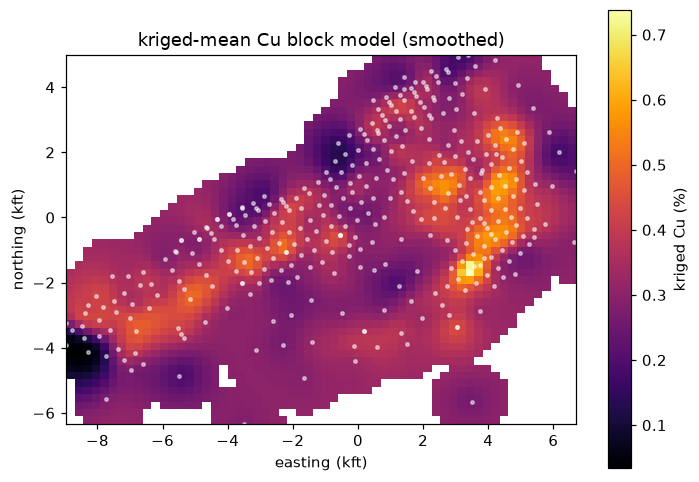

In [6]:
gx = np.linspace(xy[:,0].min(), xy[:,0].max(), 60)
gy = np.linspace(xy[:,1].min(), xy[:,1].max(), 50)
GX, GY = np.meshgrid(gx, gy); Pall = np.c_[GX.ravel(), GY.ravel()]
dnear, _ = cKDTree(xy).query(Pall); mask = dnear < 1.2                    # blocks inside the drilled footprint
P = Pall[mask]

# --- MODEL: kriging mean + full posterior covariance (the kriging variance lives on its diagonal) ---
mean_log, cov_log = gp.predict(xy, v, P, return_cov=True)                 # --- MODEL ---
kvar = np.clip(np.diag(cov_log), 0, None)                                 # kriging variance per block
cu_kriged = np.exp(mean_log + 0.5 * kvar)                                 # lognormal-corrected mean grade

print(f'{mask.sum():,} blocks in the footprint; kriged grade {cu_kriged.min():.2f}-{cu_kriged.max():.2f}% Cu')
print('--- the smoothing property, measured (log-grade variance) ---')
print(f'  variance of the DATA            : {v.var():.3f}')
print(f'  variance of the KRIGED-MEAN map : {mean_log.var():.3f}   '
      f'({mean_log.var()/v.var():.0%} of the data variance)')
print(f'  the kriged map has lost {1-mean_log.var()/v.var():.0%} of the real grade variability by construction')

km = np.full(GX.shape, np.nan).ravel(); km[mask] = cu_kriged             # for display
fig, ax = plt.subplots(figsize=(6.6, 4.6))
im = ax.imshow(km.reshape(GX.shape), origin='lower', cmap='inferno',
               extent=[gx.min(), gx.max(), gy.min(), gy.max()], aspect='equal')
ax.scatter(xy[:,0], xy[:,1], s=5, c='white', alpha=0.5)
ax.set(title='kriged-mean Cu block model (smoothed)', xlabel='easting (kft)', ylabel='northing (kft)')
fig.colorbar(im, label='kriged Cu (%)'); fig.tight_layout();

## 6. Conditional simulation: realizations that keep the variability

The kriged map answers "what is the *best single estimate* of grade in each block?" The resource question is
different: "above a cutoff, how much tonnage and at what grade — *and how sure are we*?" For that we need maps
that look like the **real deposit**: same data at the holes, same histogram, same variogram — including the full
variability the kriged mean threw away. That is **conditional simulation**.

A GP makes this exact and one-line. The posterior over the block grades is a multivariate Gaussian with the
kriged mean and the posterior covariance `cov_log`. Every draw from that Gaussian is a **realization**: it honors
the data (the posterior variance collapses to ~0 at the holes, so every realization passes through them), and
its block-to-block covariance is the fitted variogram, so it carries the right spatial texture and the right
spread. We draw a few hundred and add the **nugget** to each block so the realizations reproduce the *full*
point-support variance (nugget + structured), not just the smoothed structural part — i.e. they match the data
histogram, which is the whole point.

`np.random.RandomState(seed).multivariate_normal(mean, cov, n)` is the entire simulator.

300 conditional realizations of the block model
--- variance check: simulations restore the variability kriging smoothed away (log-grade) ---
  data variance                 : 0.174
  kriged-mean map variance      : 0.085
  mean realization variance     : 0.207   (variability restored; slightly above data as the full nugget is added at every block)


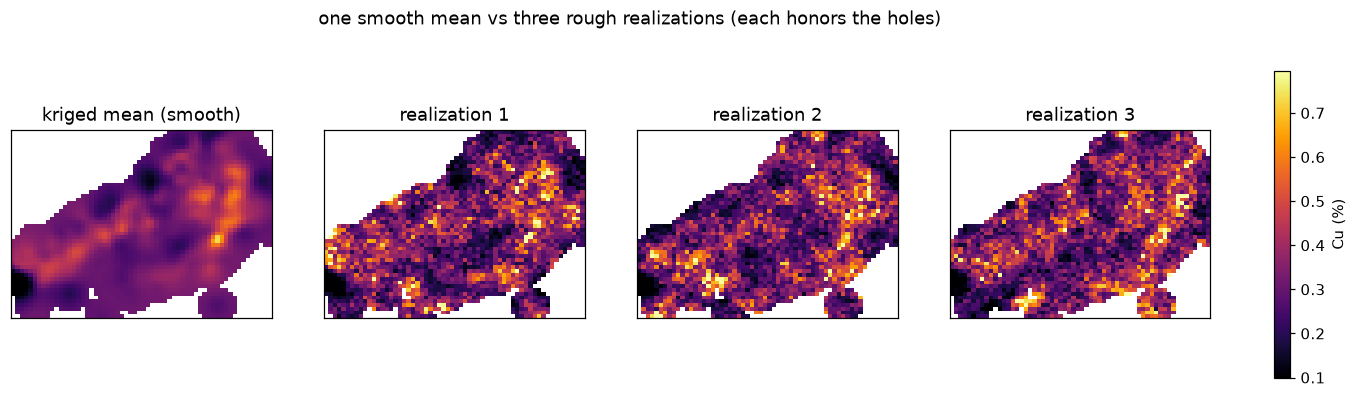

In [7]:
# --- MODEL: conditional simulation = draws from the GP posterior (mean + cov), nugget added for point support ---
nsim = 300
cov_sim = cov_log + nug**2 * np.eye(len(mean_log))                        # structural posterior + nugget
sims_log = rng.multivariate_normal(mean_log, cov_sim, nsim)              # --- MODEL ---  (nsim x nblocks)
sims_cu = np.exp(sims_log)                                                # each row = one back-transformed grade map

print(f'{nsim} conditional realizations of the block model')
print('--- variance check: simulations restore the variability kriging smoothed away (log-grade) ---')
print(f'  data variance                 : {v.var():.3f}')
print(f'  kriged-mean map variance      : {mean_log.var():.3f}')
print(f'  mean realization variance     : {np.mean([s.var() for s in sims_log]):.3f}   '
      f'(variability restored; slightly above data as the full nugget is added at every block)')

# show three realizations vs the kriged mean, same colour scale
fig, ax = plt.subplots(1, 4, figsize=(15, 3.7))
vmin, vmax = 0.1, np.percentile(sims_cu, 99)
for a, (m, t) in zip(ax, [(cu_kriged, 'kriged mean (smooth)')] +
                          [(sims_cu[k], f'realization {k+1}') for k in range(3)]):
    img = np.full(GX.size, np.nan); img[mask] = m
    im = a.imshow(img.reshape(GX.shape), origin='lower', cmap='inferno', vmin=vmin, vmax=vmax,
                  extent=[gx.min(), gx.max(), gy.min(), gy.max()], aspect='equal')
    a.set(title=t, xticks=[], yticks=[])
fig.colorbar(im, ax=ax, fraction=0.012, label='Cu (%)')
fig.suptitle('one smooth mean vs three rough realizations (each honors the holes)', y=1.02); 

The realizations are visibly **rougher** than the kriged mean and they differ from one another — that
spread *is* the resource uncertainty. They all collapse to the same values at the holes (the data is honored)
and diverge between holes, most where holes are sparse. The kriged mean is their average; selecting ore from
that average is the mistake we now quantify. (The realization variance lands a touch *above* the data variance
because adding the full nugget at every block over-disperses slightly; simulating the nugget at sample support
only would tighten it. The over-shoot is small and does not affect the direction of the bias below.)

## 7. The earned result: tonnage and grade above a cutoff, two ways

Now the punchline, in resource numbers. Pick a cutoff grade $z_c$. The two estimators of **proportion of ground
that is ore** (≡ tonnage fraction, since blocks are equal) and **mean grade of that ore** are:

- **Kriged-mean selection** — count blocks whose *kriged* grade exceeds $z_c$; average their kriged grade. This
  is what selecting ore off a single block model does.
- **Conditional simulation** — for each realization, count blocks above $z_c$ and average their grade; this
  gives a **distribution** over tonnage and grade across realizations. Its mean is the (approximately) unbiased
  estimate; its 10th-90th percentile spread is the honest uncertainty.

The theory's prediction, stated before we look: because the kriged map is too smooth, at a **low** cutoff it has
too few low values to fall below the line, so it **over-states** ore tonnage; at a **high** cutoff it has lost
the high peaks, so it **under-states** ore tonnage and the selected grade. Watch the sign flip across the
cutoff.

In [8]:
cutoffs = np.array([0.25, 0.30, 0.40, 0.50])
def ore_frac(m, c): return float((m >= c).mean())
def ore_grade(m, c): return float(m[m >= c].mean()) if (m >= c).any() else np.nan

kr_frac  = np.array([ore_frac(cu_kriged, c)  for c in cutoffs])
kr_grade = np.array([ore_grade(cu_kriged, c) for c in cutoffs])
sim_frac  = np.array([[ore_frac(sims_cu[s], c)  for c in cutoffs] for s in range(nsim)])
sim_grade = np.array([[ore_grade(sims_cu[s], c) for c in cutoffs] for s in range(nsim)])

print('TONNAGE FRACTION above cutoff      |  GRADE of selected ore (%)')
print('cutoff  kriged   sim mean[P10,P90]  bias |  kriged  sim mean   bias')
for j, c in enumerate(cutoffs):
    sf, sg = sim_frac[:, j], sim_grade[:, j]
    fb = (kr_frac[j] - sf.mean()) / sf.mean() * 100
    gb = (kr_grade[j] - np.nanmean(sg)) / np.nanmean(sg) * 100
    print(f' {c:.2f}   {kr_frac[j]:.3f}   {sf.mean():.3f}[{np.percentile(sf,10):.3f},{np.percentile(sf,90):.3f}]'
          f' {fb:+5.0f}% |  {kr_grade[j]:.3f}   {np.nanmean(sg):.3f}   {gb:+5.0f}%')

TONNAGE FRACTION above cutoff      |  GRADE of selected ore (%)
cutoff  kriged   sim mean[P10,P90]  bias |  kriged  sim mean   bias
 0.25   0.893   0.705[0.676,0.733]   +27% |  0.344   0.401     -14%
 0.30   0.633   0.548[0.516,0.578]   +16% |  0.370   0.438     -15%
 0.40   0.165   0.283[0.256,0.309]   -42% |  0.459   0.523     -12%
 0.50   0.033   0.129[0.111,0.146]   -74% |  0.547   0.617     -11%


Resource above 0.30% Cu in the drilled footprint (~6,387 Mt of rock):
  KRIGED-MEAN selection : 4,044 Mt @ 0.370% Cu
  SIMULATION (honest)   : 3,497 Mt [3,297-3,689] @ 0.438% Cu
  => kriged-mean OVER-states ore tonnage by +16% and UNDER-states grade by -15% at this cutoff


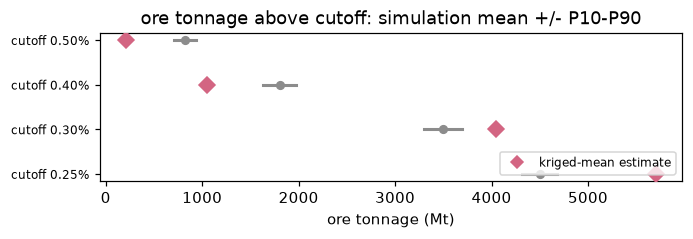

In [9]:
# Put it in tonnes, and draw the grade-tonnage uncertainty as a forest plot at the planning cutoff.
dxft, dyft = (gx[1]-gx[0])*1000, (gy[1]-gy[0])*1000
density = 0.0876                                           # short tons / ft^3  (mafic rock ~2.8 g/cc)
tons_block = dxft * dyft * gt.THK.mean() * density         # tonnes per equal-area block (mean intercept thk)
total_Mt = tons_block * mask.sum() / 1e6
to_Mt = lambda frac: frac * mask.sum() * tons_block / 1e6

j = 1; c = cutoffs[j]                                       # planning cutoff 0.30% Cu
print(f'Resource above {c:.2f}% Cu in the drilled footprint (~{total_Mt:,.0f} Mt of rock):')
print(f'  KRIGED-MEAN selection : {to_Mt(kr_frac[j]):,.0f} Mt @ {kr_grade[j]:.3f}% Cu')
print(f'  SIMULATION (honest)   : {to_Mt(sim_frac[:,j].mean()):,.0f} Mt '
      f'[{to_Mt(np.percentile(sim_frac[:,j],10)):,.0f}-{to_Mt(np.percentile(sim_frac[:,j],90)):,.0f}] '
      f'@ {np.nanmean(sim_grade[:,j]):.3f}% Cu')
print(f'  => kriged-mean OVER-states ore tonnage by {(kr_frac[j]/sim_frac[:,j].mean()-1)*100:+.0f}% '
      f'and UNDER-states grade by {(kr_grade[j]/np.nanmean(sim_grade[:,j])-1)*100:+.0f}% at this cutoff')

# forest plot: tonnage estimate +/- simulation P10-P90 at each cutoff, kriged value as the reference marker
labels = [f'cutoff {c:.2f}%' for c in cutoffs]
est = [to_Mt(sim_frac[:,j].mean()) for j in range(len(cutoffs))]
lo  = [to_Mt(np.percentile(sim_frac[:,j],10)) for j in range(len(cutoffs))]
hi  = [to_Mt(np.percentile(sim_frac[:,j],90)) for j in range(len(cutoffs))]
fig = gv.forest(labels, est, lo, hi, title='ore tonnage above cutoff: simulation mean +/- P10-P90',
                xlabel='ore tonnage (Mt)', sort=False)
ax = fig.axes[0]
for k in range(len(cutoffs)):
    ax.plot(to_Mt(kr_frac[k]), k, 'D', color='#d36582', ms=7, zorder=5)
ax.plot([], [], 'D', color='#d36582', label='kriged-mean estimate'); ax.legend(fontsize=8, loc='lower right');

There it is, with the sign flip the theory demanded. At the **0.30% planning cutoff** the kriged-mean block
model **over-states** the ore tonnage (the red diamond sits above the simulation mean) while **under-stating**
its grade — it converts marginal, below-cutoff ground into ore on paper. Push the cutoff up and the error
**reverses**: at 0.40% and 0.50% the smoothed map has lost the high-grade peaks and **under-states** the
tonnage by a wide margin (roughly a factor of two at 0.50%). The kriged map's single answer also carries **no
error bar**; the simulations deliver a P10-P90 band that is the actual resource uncertainty a mine plan must
budget against. Same data, same variogram, same kriging engine — the difference is entirely the smoothing, and
it is worth tens of percent of the tonnage estimate either side of the cutoff.

## 8. Honest limits, and the decision

These are **illustrative resource figures for teaching, not a reportable reserve**. The numbers above rest on
choices worth stating plainly:

- **2-D reduction.** Collapsing each hole to one plan-view grade ignores vertical grade structure and treats
  intercept thickness as roughly constant in the tonnage conversion. A production estimate kriges 3-D blocks.
  The smoothing/selection bias the notebook is built to show is **dimension-independent** — it is, if anything,
  sharper in 3-D.
- **No declustering.** Drilling is denser over known high-grade ground; clustered holes over-weight those
  grades in the histogram, biasing the global mean (and so the simulations' marginal distribution) high. A real
  study would cell- or polygon-decluster first.
- **Lognormal back-transform.** Working in log-grade is right for a skewed positive variable, but the
  back-transform is sensitive to the variance correction and to the upper tail; the **absolute** tonnage/grade
  numbers move with these choices. The **direction and rough magnitude of the kriged-vs-simulated bias** is the
  robust result, not the third significant figure.
- **Support / SMU.** Real selection happens on **mineable blocks (SMUs)**, not points; the change of support
  from sample to SMU is its own correction (the volume-variance relation). Point-support simulation here
  over-states the selectivity a real mine has — another reason these are illustrative.
- **Stationarity.** The variogram drifts at long lags (a regional grade trend); ordinary kriging's local
  unbiasedness absorbs much of it, but a strong trend would call for kriging-with-a-trend / universal kriging.

**The decision.** Estimate a recoverable resource from **the distribution over conditional simulations, not from
the kriged-mean block model.** Use the kriged mean for what it is best at — a smooth, locally-unbiased picture
of *where* the grade is — but read **tonnage and grade above a cutoff off the simulations**, and report them
*with* their P10-P90 band. Selecting ore from the smoothed map is biased in a cutoff-dependent direction (here:
over-states tonnage below the planning cutoff, under-states it well above) and hides the uncertainty entirely.
That bias has sunk real projects when the mill was sized to a kriged tonnage that the deposit's true variability
did not contain. The geostatistical discipline is the whole point: **the spread across realizations is the
resource estimate; a single smooth map is not.**

### References
Patelke, R. L. (1994) and NRRI compilations, Babbitt Cu-Ni-PGE drilling, University of Minnesota Duluth
(`hdl.handle.net/11299/188523`; PyGSLIB tutorial mirror). Journel, A. G. & Huijbregts, C. J. (1978),
*Mining Geostatistics*. Goovaerts, P. (1997), *Geostatistics for Natural Resources Evaluation* (the
smoothing/selection problem and conditional simulation). Chilès, J.-P. & Delfiner (2012), *Geostatistics:
Modeling Spatial Uncertainty*.